# Global Superstore – Profitability & Customer Segmentation Analysis

End-to-end exploratory data analysis using **Python and Pandas** to identify profitability drivers, loss-making segments, and customer targeting strategies.

## Business Objective

A multinational retail company operating across 147 countries wants to understand why margins are under pressure despite strong sales volume.  
This notebook investigates:

- which segments and categories generate the most value,
- where discounting starts to damage profitability,
- which regions underperform,
- and what actions leadership could take to improve margins.

> This notebook is intentionally written as a portfolio case study: clear, reproducible, and business-oriented.


## 1. Imports and setup

We will use:

- **Pandas** for data manipulation
- **NumPy** for numerical operations
- **Matplotlib / Seaborn** for visualizations


In [8]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11


## 2. Load the dataset

The `Orders` sheet contains **51,290 transaction rows (order line items)** from 2011 to 2014.


In [9]:
# Load the Excel file
file_path = "Global Superstore.xls"
sheet_name = "Orders"

df = pd.read_excel(file_path, sheet_name=sheet_name)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()


Rows: 51,290
Columns: 24


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


## 3. Initial inspection

Before cleaning anything, let's inspect structure, datatypes, and missing values.


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [11]:
df.isna().sum().sort_values(ascending=False).head(10)


Postal Code      41296
Row ID               0
Region               0
Shipping Cost        0
Profit               0
Discount             0
Quantity             0
Sales                0
Product Name         0
Sub-Category         0
dtype: int64

## 4. Data cleaning

Cleaning steps:

1. remove exact duplicate rows,
2. fill missing postal codes with `0`,
3. convert date columns to `datetime`,
4. standardize a few analytical fields for later use.


In [12]:
# Keep a copy of the raw dataframe for reference
raw_df = df.copy()

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

# Fill Postal Code missing values
df["Postal Code"] = df["Postal Code"].fillna(0).astype(int)

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(f"Rows after cleaning: {df.shape[0]:,}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique orders: {df['Order ID'].nunique():,}")


Rows after cleaning: 51,290
Unique customers: 1,590
Unique orders: 25,035


## 5. Feature engineering

We create a few derived metrics to support the analysis:

- **Profit Margin** = `Profit / Sales`
- **Shipping Cost Ratio** = `Shipping Cost / Sales`
- **Shipping Days** = `Ship Date - Order Date`
- **Discount Band** = discount grouped into business-friendly buckets


In [13]:
df["Profit_Margin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], np.nan)
df["Shipping_Cost_Ratio"] = np.where(df["Sales"] != 0, df["Shipping Cost"] / df["Sales"], np.nan)
df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

discount_bins = [-0.1, 0, 0.1, 0.2, 0.3, 1.0]
discount_labels = ["No Discount", "0-10%", "10-20%", "20-30%", "30%+"]

df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=discount_bins,
    labels=discount_labels,
    include_lowest=True
)

df[["Sales", "Profit", "Profit_Margin", "Shipping_Cost_Ratio", "Shipping_Days", "Discount_Band"]].head()


,Sales,Profit,Profit_Margin,Shipping_Cost_Ratio,Shipping_Days,Discount_Band
0,2309.650,762.1845,0.330000,0.404204,0,No Discount
1,3709.395,-288.7650,-0.077847,0.248997,2,0-10%
2,5175.171,919.9710,0.177766,0.176900,1,0-10%
3,2892.510,-96.5400,-0.033376,0.314661,2,0-10%
4,2832.960,311.5200,0.109963,0.318762,1,No Discount


## 6. Dataset overview

Quick summary of the business footprint.


In [14]:
overview = pd.DataFrame({
    "Metric": [
        "Transaction rows",
        "Unique orders",
        "Unique customers",
        "Countries",
        "Markets",
        "Date range start",
        "Date range end"
    ],
    "Value": [
        f"{len(df):,}",
        f"{df['Order ID'].nunique():,}",
        f"{df['Customer ID'].nunique():,}",
        f"{df['Country'].nunique():,}",
        f"{df['Market'].nunique():,}",
        df["Order Date"].min().date(),
        df["Order Date"].max().date()
    ]
})

overview


,Metric,Value
0,Transaction rows,"51,290"
1,Unique orders,"25,035"
2,Unique customers,"1,590"
3,Countries,147
4,Markets,7
5,Date range start,2011-01-01
6,Date range end,2014-12-31


## 7. Regional profitability

This view helps answer a simple but powerful question:

**Which regions generate revenue but fail to convert it into profit?**


In [15]:
regional_profit = (
    df.groupby("Region", as_index=False)
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Shipping_Cost=("Shipping Cost", "sum"),
          Orders=("Order ID", "nunique")
      )
)

regional_profit["Profit_Margin"] = regional_profit["Profit"] / regional_profit["Sales"]
regional_profit["Shipping_Cost_Ratio"] = regional_profit["Shipping_Cost"] / regional_profit["Sales"]

regional_profit.sort_values("Profit", ascending=False)


,Region,Sales,Profit,Shipping_Cost,Orders,Profit_Margin,Shipping_Cost_Ratio
3,Central,2.822303e+06,311403.98164,296939.1000,5249,0.110337,0.105212
7,North,1.248166e+06,194597.95252,131472.6480,2356,0.155907,0.105333
8,North Asia,8.483098e+05,165578.42100,95030.6100,1150,0.195186,0.112023
10,South,1.600907e+06,140355.76618,168472.7515,3270,0.087673,0.105236
4,Central Asia,7.528266e+05,132480.18700,77830.1500,1026,0.175977,0.103384
9,Oceania,1.100185e+06,120089.11200,120628.5100,1744,0.109154,0.109644
12,West,7.254578e+05,108418.44890,76512.2639,1611,0.149448,0.105468
6,East,6.787812e+05,91522.78000,72743.6200,1401,0.134834,0.107168
0,Africa,7.837732e+05,88871.63100,88139.4700,2232,0.113389,0.112455
5,EMEA,8.061613e+05,43897.97100,88375.7300,2462,0.054453,0.109625


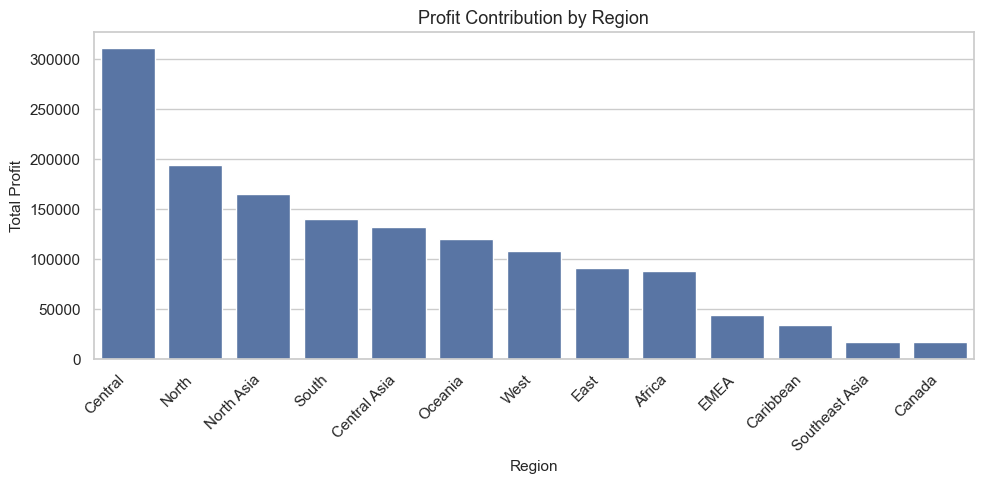

In [16]:
plot_df = regional_profit.sort_values("Profit", ascending=False)

sns.barplot(data=plot_df, x="Region", y="Profit")
plt.title("Profit Contribution by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Regional takeaways

A useful twist here is not just looking at profit, but comparing it with **shipping cost ratio**.  
That often reveals why a region can sell a lot and still feel financially underwhelming.


In [17]:
regional_profit.sort_values(["Profit", "Shipping_Cost_Ratio"], ascending=[True, False]).head(8)


,Region,Sales,Profit,Shipping_Cost,Orders,Profit_Margin,Shipping_Cost_Ratio
1,Canada,6.692817e+04,17817.39000,7405.6300,201,0.266217,0.110650
11,Southeast Asia,8.844232e+05,17852.32900,93675.8440,1517,0.020185,0.105917
2,Caribbean,3.242809e+05,34571.32104,35589.3760,855,0.106609,0.109749
5,EMEA,8.061613e+05,43897.97100,88375.7300,2462,0.054453,0.109625
0,Africa,7.837732e+05,88871.63100,88139.4700,2232,0.113389,0.112455
6,East,6.787812e+05,91522.78000,72743.6200,1401,0.134834,0.107168
12,West,7.254578e+05,108418.44890,76512.2639,1611,0.149448,0.105468
9,Oceania,1.100185e+06,120089.11200,120628.5100,1744,0.109154,0.109644


## 8. Discount impact analysis

This is one of the most decision-friendly sections of the notebook.

Instead of analyzing discount as a messy continuous variable, we group it into ranges:

- No Discount
- 0–10%
- 10–20%
- 20–30%
- 30%+

That makes the margin story much easier to explain to stakeholders without statistical smoke machines.


In [18]:
discount_margin = (
    df.groupby("Discount_Band", observed=False)
      .agg(
          Avg_Profit_Margin=("Profit_Margin", "mean"),
          Total_Profit=("Profit", "sum"),
          Orders=("Order ID", "nunique"),
          Rows=("Order ID", "size")
      )
      .reset_index()
)

discount_margin


,Discount_Band,Avg_Profit_Margin,Total_Profit,Orders,Rows
0,No Discount,0.264898,1.770695e+06,15211,29009
1,0-10%,0.171293,3.381893e+05,3028,4679
2,10-20%,0.137450,1.732548e+05,4363,6274
3,20-30%,-0.038511,-2.115561e+04,843,967
4,30%+,-0.663871,-7.935265e+05,5794,10361


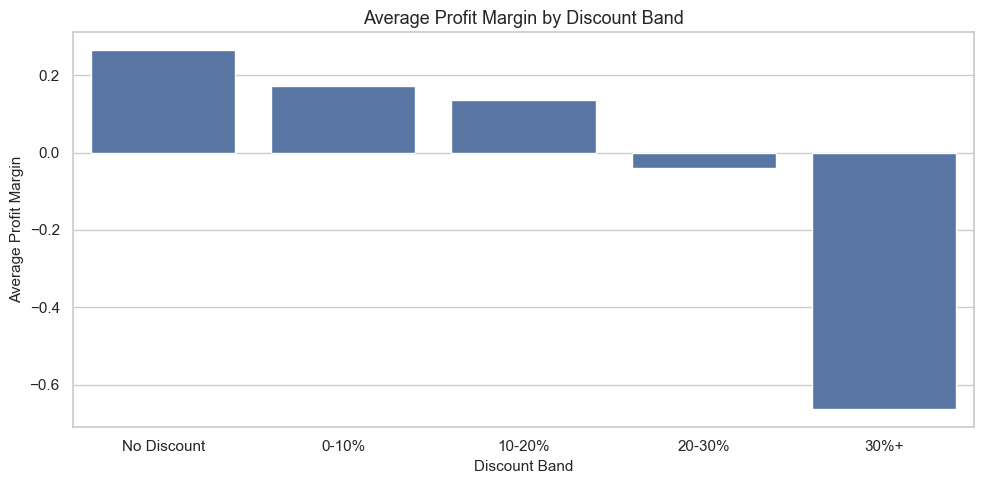

In [19]:
sns.barplot(data=discount_margin, x="Discount_Band", y="Avg_Profit_Margin")
plt.title("Average Profit Margin by Discount Band")
plt.xlabel("Discount Band")
plt.ylabel("Average Profit Margin")
plt.tight_layout()
plt.show()


### Interpretation

The key point is not that **every** order above 20% discount loses money.  
The more defensible claim is this:

> Discounts above 20% produce **negative margins on average**.

That phrasing is statistically cleaner and much harder for a reviewer to poke holes in.


## 9. Sales vs. profit by segment

A scatter plot helps us inspect volatility, outliers, and whether certain segments generate more loss-making orders.


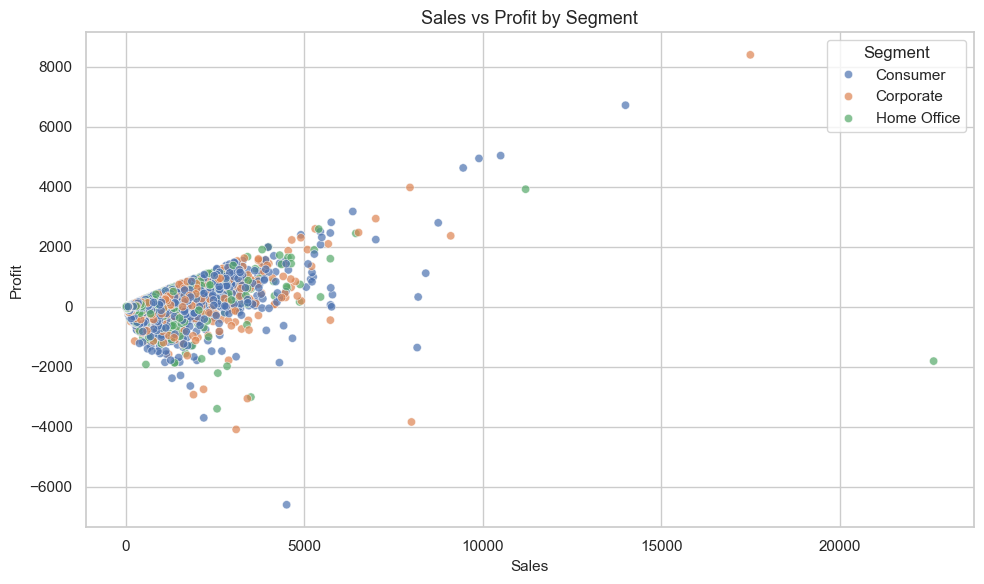

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Sales", y="Profit", hue="Segment", alpha=0.7)
plt.title("Sales vs Profit by Segment")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


## 10. Segment profitability

Now we move from individual orders to strategic customer segments.


In [21]:
segment_summary = (
    df.groupby("Segment")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Customers=("Customer ID", "nunique"),
          Orders=("Order ID", "nunique")
      )
)

segment_summary["Profit_per_Customer"] = segment_summary["Profit"] / segment_summary["Customers"]
segment_summary["Profit_Share"] = segment_summary["Profit"] / segment_summary["Profit"].sum()

segment_summary.sort_values("Profit", ascending=False)


,Sales,Profit,Customers,Orders,Profit_per_Customer,Profit_Share
Segment,,,,,,
Consumer,6.507949e+06,749239.78206,818,13104,915.941054,0.510570
Corporate,3.824698e+06,441208.32866,476,7673,926.908253,0.300662
Home Office,2.309855e+06,277009.18056,296,4687,935.841826,0.188768


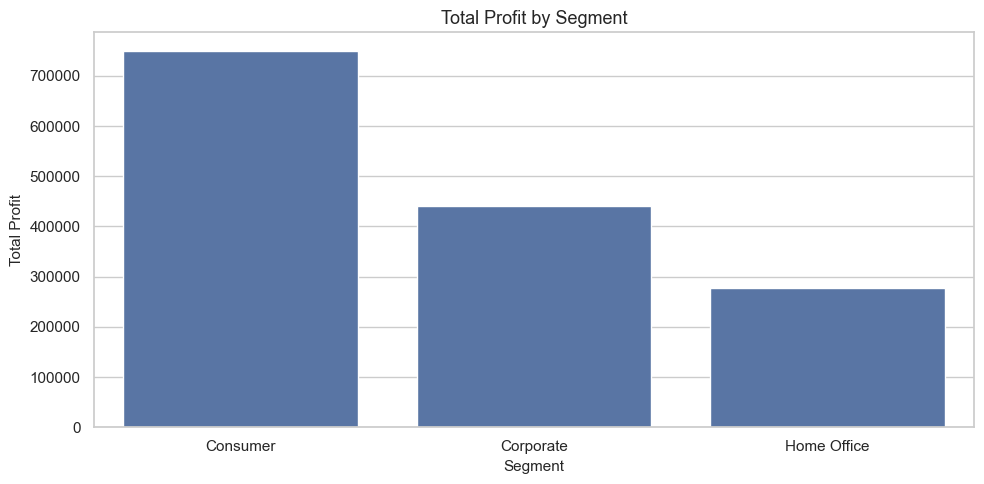

In [22]:
segment_plot = segment_summary.reset_index().sort_values("Profit", ascending=False)

sns.barplot(data=segment_plot, x="Segment", y="Profit")
plt.title("Total Profit by Segment")
plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()


## 11. Category and sub-category profitability

This section identifies which product families deserve more commercial attention.


In [23]:
category_summary = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
)

category_summary["Profit_Margin"] = category_summary["Profit"] / category_summary["Sales"]
category_summary.sort_values("Profit_Margin", ascending=False)


,Sales,Profit,Profit_Margin
Category,,,
Technology,4.744557e+06,663778.73318,0.139903
Office Supplies,3.787070e+06,518473.83430,0.136906
Furniture,4.110874e+06,285204.72380,0.069378


In [24]:
subcategory_summary = (
    df.groupby("Sub-Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
)

subcategory_summary["Profit_Margin"] = subcategory_summary["Profit"] / subcategory_summary["Sales"]

subcategory_summary.sort_values("Profit_Margin", ascending=False).head(10)


,Sales,Profit,Profit_Margin
Sub-Category,,,
Paper,2.442917e+05,59207.68270,0.242365
Labels,7.340403e+04,15010.51200,0.204492
Envelopes,1.709043e+05,29601.11630,0.173203
Accessories,7.492370e+05,129626.30620,0.173011
Copiers,1.509436e+06,258567.54818,0.171301
Binders,4.619115e+05,72449.84600,0.156848
Art,3.720920e+05,57953.91090,0.155752
Appliances,1.011064e+06,141680.58940,0.140130
Fasteners,8.324232e+04,11525.42410,0.138456


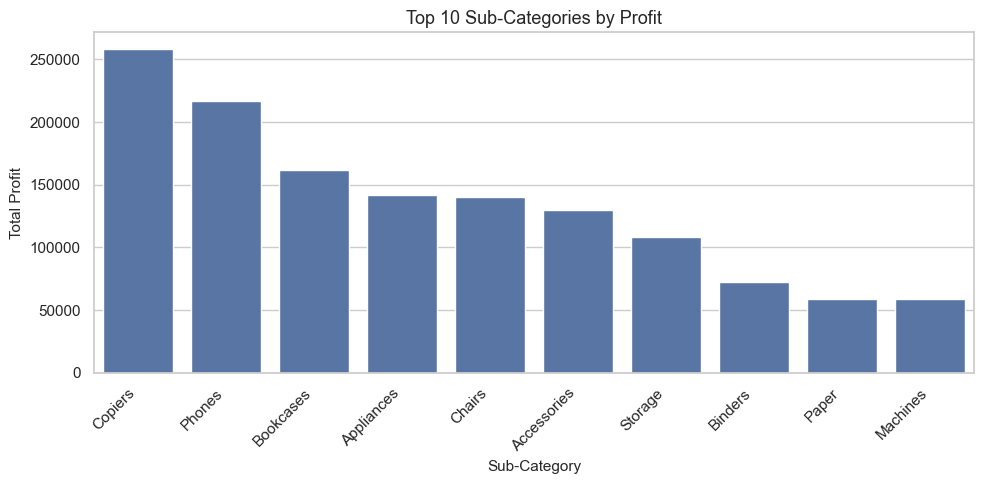

In [25]:
top_subcats = (
    subcategory_summary.sort_values("Profit", ascending=False)
    .head(10)
    .reset_index()
)

sns.barplot(data=top_subcats, x="Sub-Category", y="Profit")
plt.title("Top 10 Sub-Categories by Profit")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 12. Export lightweight JSON for frontend use

This is optional for analysis, but useful if you want your React / Recharts portfolio site to consume pre-aggregated data from Python.


In [26]:
top_regions = (
    regional_profit.sort_values("Profit", ascending=False)
    .head(4)[["Region", "Profit"]]
)

bottom_regions = (
    regional_profit.sort_values("Profit", ascending=True)
    .head(3)[["Region", "Profit"]]
)

regional_json_df = pd.concat([top_regions, bottom_regions], ignore_index=True)
regional_data = (
    regional_json_df.rename(columns={"Region": "region", "Profit": "profit"})
    .to_dict(orient="records")
)

discount_data = (
    discount_margin.rename(columns={"Discount_Band": "band", "Avg_Profit_Margin": "margin"})
    [["band", "margin"]]
    .assign(margin=lambda x: x["margin"].round(4))
    .to_dict(orient="records")
)

frontend_payload = {
    "regional_data": regional_data,
    "discount_data": discount_data
}

print(json.dumps(frontend_payload, indent=2, default=str))


{
  "regional_data": [
    {
      "region": "Central",
      "profit": 311403.98163999995
    },
    {
      "region": "North",
      "profit": 194597.95252
    },
    {
      "region": "North Asia",
      "profit": 165578.421
    },
    {
      "region": "South",
      "profit": 140355.76617999998
    },
    {
      "region": "Canada",
      "profit": 17817.39
    },
    {
      "region": "Southeast Asia",
      "profit": 17852.32899999999
    },
    {
      "region": "Caribbean",
      "profit": 34571.32104
    }
  ],
  "discount_data": [
    {
      "band": "No Discount",
      "margin": 0.2649
    },
    {
      "band": "0-10%",
      "margin": 0.1713
    },
    {
      "band": "10-20%",
      "margin": 0.1374
    },
    {
      "band": "20-30%",
      "margin": -0.0385
    },
    {
      "band": "30%+",
      "margin": -0.6639
    }
  ]
}


## 13. Executive findings

Based on the dataset used in this notebook, the strongest portfolio-ready findings are:

1. **High discounts are margin killers.**  
   Orders discounted above 20% produce negative margins on average, especially in the 30%+ band.

2. **Consumer leads in total profit, but segment economics deserve nuance.**  
   Total profit, profit per customer, and order concentration can point to slightly different strategic choices.

3. **Regional performance is uneven.**  
   Some regions show weak profits relative to sales and shipping burden, which suggests operational inefficiency rather than demand weakness.

4. **Technology and selected sub-categories are strong profit engines.**  
   They deserve tighter inventory planning and commercial focus.

That last point is classic analytics wisdom: revenue can look glamorous while margin quietly sneaks out the back door wearing your wallet.


## 14. Business recommendations

### 1) Introduce discount guardrails
Use 20% as a soft threshold for review and approval.  
Above that point, margins deteriorate sharply on average.

### 2) Revisit pricing and promotions by segment
Rather than broad discounts, test targeted offers by customer segment and basket profile.

### 3) Audit weak regions operationally
Compare shipping cost burden, order mix, and product composition in underperforming regions.

### 4) Lean into high-margin categories
Protect stock availability and pricing strategy in categories and sub-categories with strong margins.

### 5) Evolve the project
A strong next step would be:
- customer RFM segmentation,
- churn / repeat-purchase prediction,
- or market basket analysis for cross-sell opportunities.


## 15. Final note for portfolio presentation

This notebook is designed to complement a portfolio website.

A very clean message to add to your project page is:

> *The full analysis was developed in Python using Pandas, Matplotlib and Seaborn.  
> The website uses interactive charts for presentation, while this notebook contains the original analytical workflow and business reasoning.*

That sentence removes confusion instantly and makes the project look more professional, not less.
